# Imports

In [37]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import tensorflow as tf
import zipfile
import os
from tensorflow.keras.layers import Input
from tensorflow.keras.layers import Conv2D
from tensorflow.keras.layers import MaxPooling2D
from tensorflow.keras.layers import UpSampling2D
from tensorflow.keras.models import Model

# Load the Dataset

In [38]:
zip_path = "/content/MNIST.zip"

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall("/content")

print("Dataset Extracted Successfully!")

Dataset Extracted Successfully!


In [39]:
import tensorflow as tf

train_path = "/content/mnist_png/training"
test_path = "/content/mnist_png/testing"

train_dataset = tf.keras.preprocessing.image_dataset_from_directory(train_path,labels="inferred",
    label_mode="int",
    color_mode="grayscale",
    image_size=(28,28),
    batch_size=None,
    shuffle=True
)
test_dataset = tf.keras.preprocessing.image_dataset_from_directory(test_path,labels="inferred",label_mode="int",
    color_mode="grayscale",
    image_size=(28,28),
    batch_size=None,
    shuffle=False
)

Found 60000 files belonging to 10 classes.
Found 10000 files belonging to 10 classes.


# Images -> Arrays

In [40]:
x_train = []
x_test = []
for image, label in train_dataset:
    x_train.append(image.numpy())
for image, label in test_dataset:
    x_test.append(image.numpy())
x_train = np.array(x_train)
x_test = np.array(x_test)
print("Training Shape :", x_train.shape)
print("Testing Shape :", x_test.shape)

Training Shape : (60000, 28, 28, 1)
Testing Shape : (10000, 28, 28, 1)


# Normalize the images

In [41]:
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

**Initial Images**

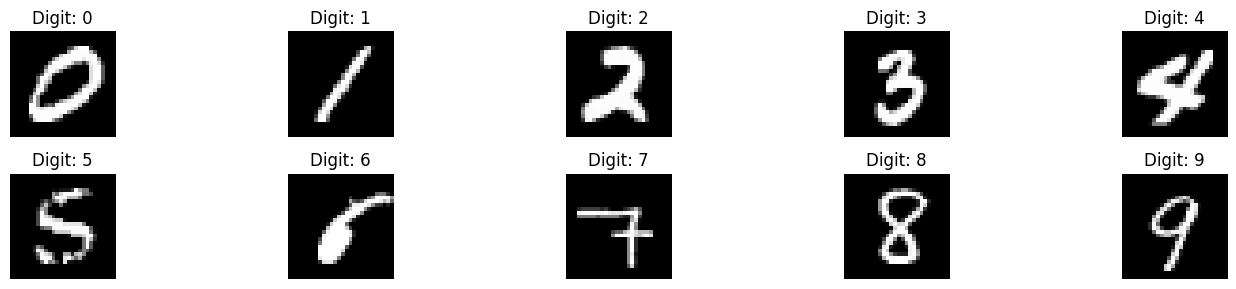

In [42]:
plt.figure(figsize=(15,3))
shown = [False] * 10
for image, label in train_dataset:
    digit = label.numpy()
    if not shown[digit]:
        plt.subplot(2, 5, digit + 1)
        plt.imshow(image.numpy().reshape(28,28), cmap='gray')
        plt.title(f"Digit: {digit}")
        plt.axis('off')
        shown[digit] = True
    if all(shown):
        break
plt.tight_layout()
plt.show()

# Adding Noise to Images

In [43]:
noise_factor = 0.5
x_train_noisy = x_train + noise_factor * np.random.normal(
    loc=0.0,
    scale=1.0,
    size=x_train.shape
)
x_test_noisy = x_test + noise_factor * np.random.normal(
    loc=0.0,
    scale=1.0,
    size=x_test.shape
)
x_train_noisy = np.clip(x_train_noisy,0.,1.)
x_test_noisy = np.clip(x_test_noisy,0.,1.)

**Images after adding noise**

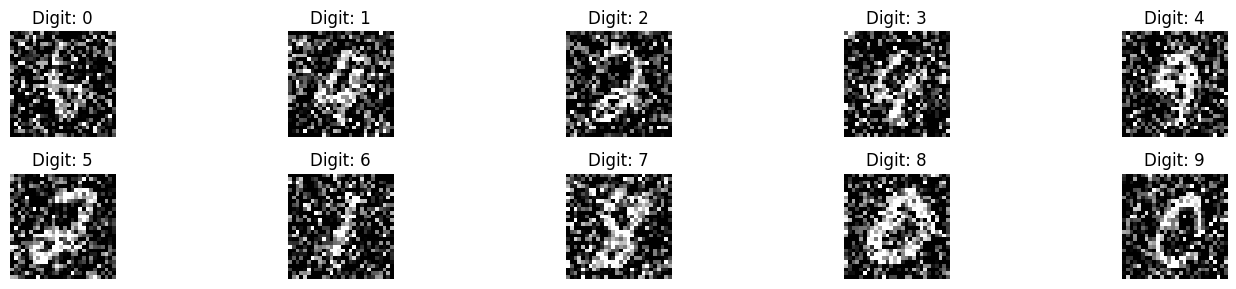

In [44]:
plt.figure(figsize=(15,3))
shown = [False] * 10
for i, (image, label) in enumerate(train_dataset):
    digit = label.numpy()

    if not shown[digit]:
        plt.subplot(2, 5, digit + 1)
        plt.imshow(x_train_noisy[i].reshape(28,28), cmap='gray')
        plt.title(f"Digit: {digit}")
        plt.axis('off')
        shown[digit] = True

    if all(shown):
        break
plt.tight_layout()
plt.show()

# Creating an AutoEncoder

In [45]:
input_img = Input(shape=(28,28,1))

x = Conv2D(32,(3,3),activation="relu",padding="same")(input_img)
x = MaxPooling2D((2,2),padding="same")(x)

x = Conv2D(16,(3,3),activation="relu",padding="same")(x)
encoded = MaxPooling2D((2,2),padding="same")(x)

x = Conv2D(16,(3,3),activation="relu",padding="same")(encoded)
x = UpSampling2D((2,2))(x)

x = Conv2D(32,(3,3),activation="relu",padding="same")(x)
x = UpSampling2D((2,2))(x)

decoded = Conv2D(1,(3,3),
                 activation="sigmoid",
                 padding="same")(x)

autoencoder = Model(input_img, decoded)

**Compile the Model**

In [46]:
autoencoder.compile(optimizer="adam",loss="binary_crossentropy")
print("AutoEncoder Details")
autoencoder.summary()

AutoEncoder Details


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 14, 14, 16)     │         4,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 7, 7, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 7, 7, 16)       │         2,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_2 (UpSampling2D)  │ (None, 14, 14, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 14, 14, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_3 (UpSampling2D)  │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,193 (47.63 KB)

 Trainable params: 12,193 (47.63 KB)

 Non-trainable params: 0 (0.00 B)

# Train the Model

In [47]:
history = autoencoder.fit(
    x_train_noisy,
    x_train,
    epochs=10,
    batch_size=128,
    shuffle=True,
    validation_data=(x_test_noisy,x_test)
)

Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 9s 13ms/step - loss: 0.1734 - val_loss: 0.1212
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.1173 - val_loss: 0.1125
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.1117 - val_loss: 0.1090
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.1089 - val_loss: 0.1068
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.1070 - val_loss: 0.1052
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.1055 - val_loss: 0.1039
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.1042 - val_loss: 0.1026
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - loss: 0.1032 - val_loss: 0.1021
Epoch 9/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.1025 - val_loss: 0.1012
Epoch 10/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.1017 - val_loss: 0.1005


**Loss Plot**

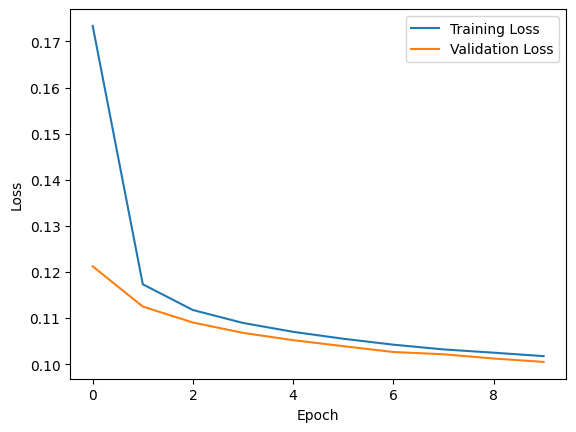

In [48]:
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

# Predictions

In [49]:
decoded_images = autoencoder.predict(x_test_noisy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


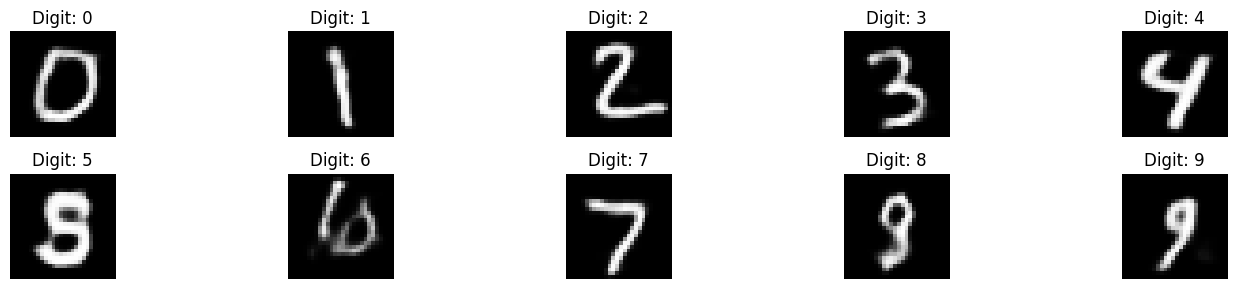

In [50]:

plt.figure(figsize=(15,3))
shown = [False] * 10
for i, (image, label) in enumerate(test_dataset):
    digit = label.numpy()
    if not shown[digit]:
        plt.subplot(2, 5, digit + 1)
        plt.imshow(decoded_images[i].reshape(28,28), cmap='gray')
        plt.title(f"Digit: {digit}")
        plt.axis('off')
        shown[digit] = True
    if all(shown):
        break

plt.tight_layout()
plt.show()

In [51]:
from sklearn.metrics import mean_squared_error

mse_noisy = []
mse_denoised = []

for i in range(len(x_test)):
    mse_noisy.append(
        mean_squared_error(
            x_test[i].flatten(),
            x_test_noisy[i].flatten()
        )
    )

    mse_denoised.append(
        mean_squared_error(
            x_test[i].flatten(),
            decoded_images[i].flatten()
        )
    )

print("Average MSE (Original vs Noisy):", np.mean(mse_noisy))
print("Average MSE (Original vs Denoised):", np.mean(mse_denoised))

Average MSE (Original vs Noisy): 0.11564321990783874
Average MSE (Original vs Denoised): 0.012433582290541381


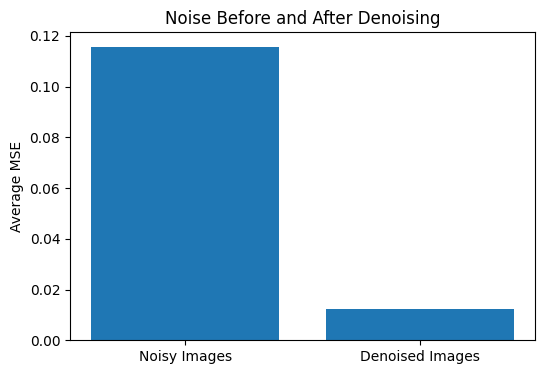

In [52]:
plt.figure(figsize=(6,4))

plt.bar(
    ["Noisy Images", "Denoised Images"],
    [np.mean(mse_noisy), np.mean(mse_denoised)]
)

plt.ylabel("Average MSE")
plt.title("Noise Before and After Denoising")

plt.show()

# Conclusion

**Comparision of Images intial images vs Noised images vs after removing Noise**

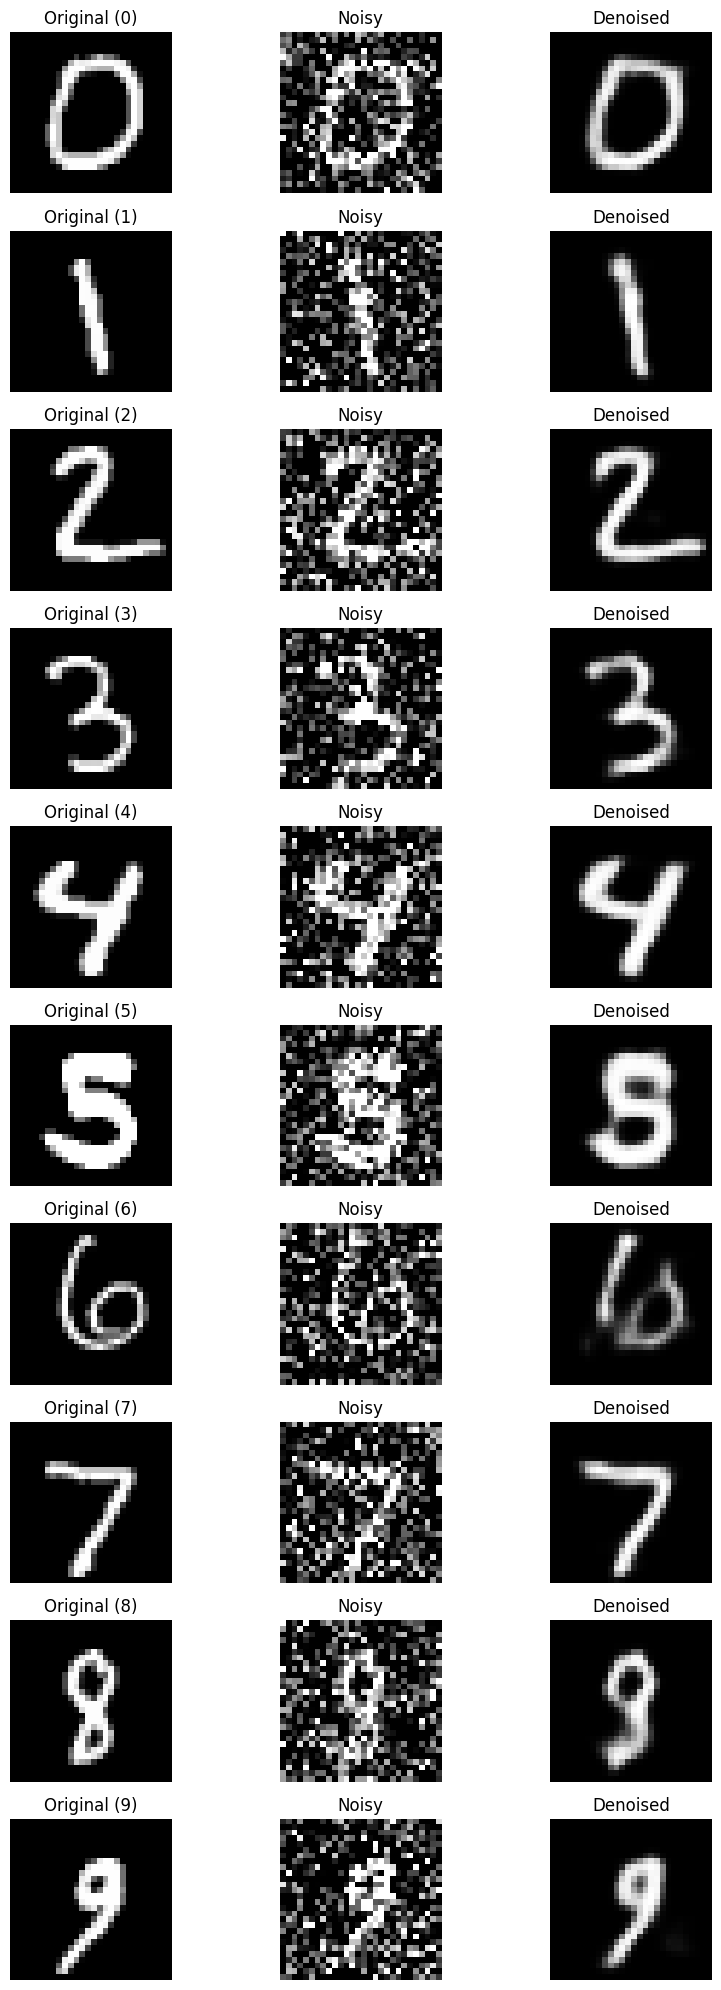

In [53]:

plt.figure(figsize=(9, 20))
shown = [False] * 10

for i, (image, label) in enumerate(test_dataset):
    digit = label.numpy()

    if not shown[digit]:

        plt.subplot(10, 3, digit*3 + 1)
        plt.imshow(x_test[i].reshape(28,28), cmap='gray')
        plt.title(f"Original ({digit})")
        plt.axis('off')

        plt.subplot(10, 3, digit*3 + 2)
        plt.imshow(x_test_noisy[i].reshape(28,28), cmap='gray')
        plt.title("Noisy")
        plt.axis('off')

        plt.subplot(10, 3, digit*3 + 3)
        plt.imshow(decoded_images[i].reshape(28,28), cmap='gray')
        plt.title("Denoised")
        plt.axis('off')

        shown[digit] = True

    if all(shown):
        break

plt.tight_layout()
plt.show()

The Convolutional Denoising Autoencoder was successfully implemented using the MNIST dataset. Random noise was added to the images, and the model learned to reconstruct clean images from the noisy inputs. The decrease in training and validation loss showed that the model learned the denoising process effectively. The final results demonstrated that the reconstructed images were close to the original images, showing that the autoencoder can effectively remove noise from images.
